# SEAS5 monitoring 2026

<!-- markdownlint-disable MD013 -->

Monitoring SEAS5 forecast for 2026 updated framework.

Trigger if AOI has at least 50% of area with seasonal rainfall in lowest tercile.

In [74]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
import calendar

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from scipy.stats import percentileofscore
from dask.diagnostics import ProgressBar

from src.datasources import seas5, codab
from src.constants import *
from src.utils.raster import upsample_dataarray

In [76]:
THRESH = 1 / 3

## Load data

### CODAB

In [78]:
# adm1 = codab.load_codab_from_blob(admin_level=1, aoi_only=True)
adm2 = codab.load_codab_from_blob(admin_level=2)
adm2_aoi = adm2[adm2["ADM2_PCODE"].isin(AOI_ADM2_PCODES_2026)]

### SEAS5 current

In [79]:
year = 2026

In [80]:
mo_lt_combos = [{"mo": 4, "lts": [2, 3, 4, 5, 6]}]

In [81]:
mo_lt_combos

[{'mo': 4, 'lts': [2, 3, 4, 5, 6]}]

In [82]:
da_seas5 = seas5.open_seas5_rasters(mo_lt_combos=mo_lt_combos, years=[year])

  0%|          | 0/1 [00:00<?, ?it/s]

In [85]:
# squeeze to remove issued_month
da_seas5_tri = da_seas5.mean(dim="lt").squeeze(drop=True)
da_seas5_up = upsample_dataarray(da_seas5_tri)
da_seas5_clip = da_seas5_up.rio.clip(adm2_aoi.geometry)

In [86]:
with ProgressBar():
    da_seas5_current_computed = da_seas5_clip.compute()

[########################################] | 100% Completed | 106.39 ms


In [87]:
da_seas5_current_computed

<xarray.DataArray (y: 21, x: 38)> Size: 3kB
array([[      nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan, 3.2856345, 3.2575207,       nan,       nan,
              nan,       nan],
       [      nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan, 3.0632086, 3.0632086, 3.0467825, 3.0467825, 3.0467825,
              nan,       nan],
       [      nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
        3.0632086, 3.0632086, 3.0632086, 3.0467825, 3.0467825, 3.0467825,
...
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan, 1.8802999, 1.8992628,
        1.8992628, 1.8992628, 1.8992628, 1.8426208, 1.8426208, 1.8426208,
        1.8426208, 1.8147042, 1.8147042, 1.8147042, 1.8147042,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan],
       [      nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan, 1.8992628,
        1.8992628, 1.8992628, 1.8992628, 1.8426208, 1.8426208, 1.8426208,
        1.8426208, 1.8147042, 1.8147042, 1.8147042, 1.8147042,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan],
       [      nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
        1.8992628, 1.8992628, 1.8992628, 1.8426208, 1.8426208, 1.8426208,
        1.8426208, 1.8147042,       nan,       nan,       nan,       nan,
              nan,       nan,       nan,       nan,       nan,       nan,
              nan,       nan]], dtype=float32)
Coordinates:
  * x            (x) float64 304B -2.6 -2.5 -2.4 -2.3 -2.2 ... 0.8 0.9 1.0 1.1
  * y            (y) float64 168B 13.0 13.1 13.2 13.3 ... 14.7 14.8 14.9 15.0
    spatial_ref  int64 8B 0

### SEAS5 historical

In [88]:
# only open the rasters for this window
da_seas5_historical = seas5.open_seas5_rasters(mo_lt_combos=mo_lt_combos)

  0%|          | 0/45 [00:00<?, ?it/s]

In [90]:
# squeeze to remove issued_month
da_seas5_tri_h = da_seas5_historical.mean(dim="lt").squeeze(drop=True)
da_seas5_up_h = upsample_dataarray(da_seas5_tri_h)
da_seas5_clip_h = da_seas5_up_h.rio.clip(adm2_aoi.geometry)

In [91]:
with ProgressBar():
    da_seas5_historical_computed = da_seas5_clip_h.compute()

[########################################] | 100% Completed | 147.90 s


In [92]:
da_seas5_historical_computed

<xarray.DataArray (year: 45, y: 21, x: 38)> Size: 144kB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 3.300801 ,       nan,
               nan],
        [      nan,       nan,       nan, ..., 3.300801 ,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 3.3250365,       nan,
               nan],
        [      nan,       nan,       nan, ..., 3.3250365,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 3.2667854,       nan,
               nan],
        [      nan,       nan,       nan, ..., 3.2667854,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * year         (year) int64 360B 1981 1982 1983 1984 ... 2022 2023 2024 2025
  * x            (x) float64 304B -2.6 -2.5 -2.4 -2.3 -2.2 ... 0.8 0.9 1.0 1.1
  * y            (y) float64 168B 13.0 13.1 13.2 13.3 ... 14.7 14.8 14.9 15.0
    spatial_ref  int64 8B 0

## Evaluate trigger

### Calculate pixel-wise percentile

Note that this excludes the current year from the percentile calculation (provided that the current year is not within the reference period 1981-2024), so the distribution doesn't change between monitoring years.

In [93]:
# count the years where value is less than or equal to current value
# then divide by total number of years - this is the percentile rank

# taken together, these two steps are equivalent to taking the mean of the
# boolean of the historical years under/over current value, per pixel

# note that we need to mask again by the NaN areas, since the boolean
# will return False for NaN pixels, instead of NaN

da_current_percentile = (
    (da_seas5_historical_computed <= da_seas5_current_computed)
    .mean(dim="year")
    .where(~da_seas5_current_computed.isnull())
)

In [94]:
da_current_percentile.max()

<xarray.DataArray ()> Size: 8B
array(0.44444444)
Coordinates:
    spatial_ref  int64 8B 0

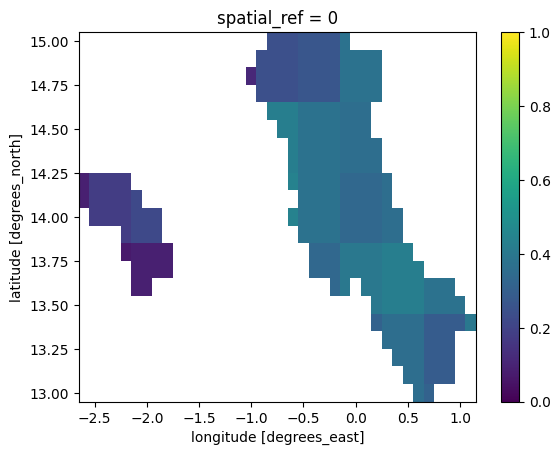

In [95]:
# just check that it looks sensible
da_current_percentile.plot(vmin=0, vmax=1)

### Calculate spatial quantile

Take the median. It it's below the theshold (33%), trigger.

In [97]:
da_current_percentile.median(dim=["x", "y"])

<xarray.DataArray ()> Size: 8B
array(0.35555556)
Coordinates:
    spatial_ref  int64 8B 0

Conversely we can look at the fraction of the area under the threshold. If it's above 50%, trigger.

In [104]:
da_triggering = (da_current_percentile < THRESH).where(
    ~da_current_percentile.isnull()
)

In [105]:
frac_area_triggering = float(da_triggering.mean())
frac_area_triggering

0.35398230088495575

## Plotting

In [106]:
mo = mo_lt_combos[0].get("mo")

In [107]:
mo_fr = FRENCH_MONTHS.get(calendar.month_abbr[mo])

In [108]:
v_mo_fr = ", ".join(
    [
        FRENCH_MONTHS.get(calendar.month_abbr[x + mo])
        for x in mo_lt_combos[0].get("lts")
    ]
)

(-2.8400000000100705, 1.339999999989692)

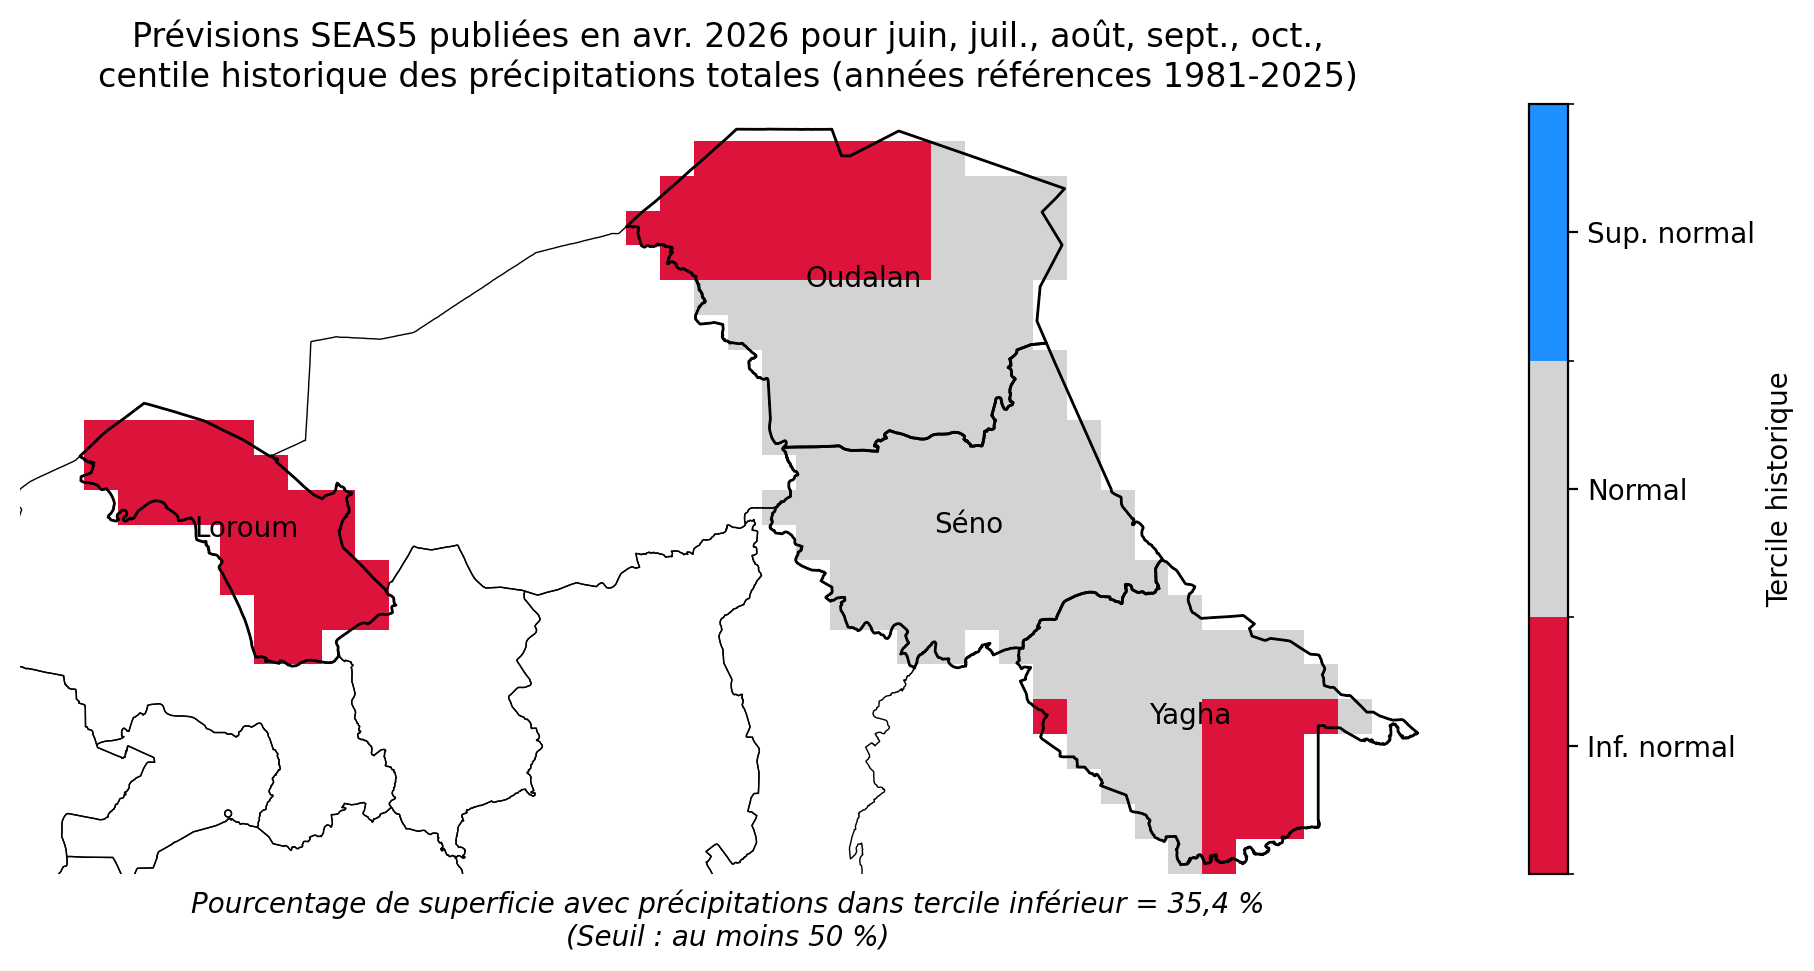

In [127]:
boundaries = [0, 1 / 3, 2 / 3, 1.0]
colors = [
    "crimson",
    "lightgrey",
    "dodgerblue",
]  # below normal, near normal, above normal
# Create a custom colormap
cmap = mcolors.ListedColormap(colors)
# Normalize the values to the specified boundaries
norm = mcolors.BoundaryNorm(boundaries, cmap.N)
# Plot the data
fig, ax = plt.subplots(dpi=200, figsize=(12, 5))
da_current_percentile.plot(cmap=cmap, norm=norm, ax=ax, add_colorbar=False)
ax.axis("off")
adm2_aoi.boundary.plot(ax=ax, color="k", linewidth=1)
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
ax.set_title(
    f"Prévisions SEAS5 publiées en {mo_fr} {year} pour {v_mo_fr},\n"
    "centile historique des précipitations totales (années références 1981-2025)"
)
bottom_text = (
    f"Pourcentage de superficie avec précipitations dans tercile inférieur = {frac_area_triggering*100:.1f} %\n"
    "(Seuil : au moins 50 %)"
).replace(".", ",")
ax.text(
    0.5,
    -0.1,
    bottom_text,
    ha="center",
    va="bottom",
    transform=ax.transAxes,
    fontsize=10,
    style="italic",
    color="black",
)
adm2_aoi.boundary.plot(ax=ax, color="k", linewidth=0.5)

# Add ADM2 labels
for _, row in adm2_aoi.iterrows():
    ax.annotate(
        row["ADM2_FR"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center",
        va="center",
        fontsize=10,
        color="black",
    )
cbar = plt.colorbar(
    ax.collections[0], ax=ax, norm=norm, cmap=cmap, boundaries=boundaries
)
cbar.set_label("Tercile historique")
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}e"))
cbar.set_ticks([1 / 6, 1 / 2, 5 / 6])
cbar.set_ticklabels(["Inf. normal", "Normal", "Sup. normal"])

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.05)
ax.set_xlim(xmin - (xmax - xmin) * 0.05, xmax + (xmax - xmin) * 0.05)

## Testing

We can verify that this method of percentile rank calculation correponds to that for the threshold calculation by running the monitoring for the year 2024 and comparing the results

In [65]:
# calculate rank using method in thresholds
da_seas5_historical_ranks = da_seas5_historical_computed.rank(
    dim="year", pct=True
)

In [66]:
da_check = da_seas5_historical_ranks.sel(year=year) == da_current_percentile

KeyError: "not all values found in index 'year'. Try setting the `method` keyword argument (example: method='nearest')."

In [ ]:
# check by plotting- values match everywhere
da_check.plot()